In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving churn_dataset.csv to churn_dataset.csv


In [ ]:
df = pd.read_csv("churn_dataset.csv")
df.head()

,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,...,France,Germany,Spain,Female,Male,Mem__no__Products,Cred_Bal_Sal,Bal_sal,Tenure_Age,Age_Tenure_product
0,2023,668,33.0,3,0.00,2,1,0,31877,0,...,1,0,0,0,1,0,0,0,372,99.0
1,2024,627,33.0,1,0.00,2,1,1,38638,0,...,1,0,0,0,1,2,0,0,249,33.0
2,1236,678,40.0,10,0.00,2,1,0,33019,0,...,1,0,0,0,1,0,0,0,14,400.0
3,1362,581,34.0,2,148882.54,1,1,1,49779,0,...,1,0,0,0,1,1,3738,21551,308,68.0
4,491,716,33.0,5,0.00,2,1,1,19305,0,...,0,0,1,0,1,2,0,0,130,165.0


In [ ]:
# SELECT ONLY REQUIRED FEATURES
df = df[['CreditScore', 'Age', 'Tenure',
    'Balance', 'NumOfProducts', 'HasCrCard',
    'IsActiveMember', 'EstimatedSalary',
    'Female', 'Male', 'France', 'Germany', 'Spain',
    'Exited']]
print(df.head())

   CreditScore   Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          668  33.0       3       0.00              2          1   
1          627  33.0       1       0.00              2          1   
2          678  40.0      10       0.00              2          1   
3          581  34.0       2  148882.54              1          1   
4          716  33.0       5       0.00              2          1   

   IsActiveMember  EstimatedSalary  Female  Male  France  Germany  Spain  \
0               0            31877       0     1       1        0      0   
1               1            38638       0     1       1        0      0   
2               0            33019       0     1       1        0      0   
3               1            49779       0     1       1        0      0   
4               1            19305       0     1       0        0      1   

   Exited  
0       0  
1       0  
2       0  
3       0  
4       0  


In [ ]:
#encoding here is not reqd since my dataset already has it encoded as in geography is given as france, spain etc and male and female also sep instead of gender.
''' Gender → Label Encoding
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

# Geography → One-hot Encoding
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# verify columns
print("\nColumns after encoding:\n", df.columns)'''

' Gender → Label Encoding\nle_gender = LabelEncoder()\ndf[\'Gender\'] = le_gender.fit_transform(df[\'Gender\'])\n\n# Geography → One-hot Encoding\ndf = pd.get_dummies(df, columns=[\'Geography\'], drop_first=True)\n\n# verify columns\nprint("\nColumns after encoding:\n", df.columns)'

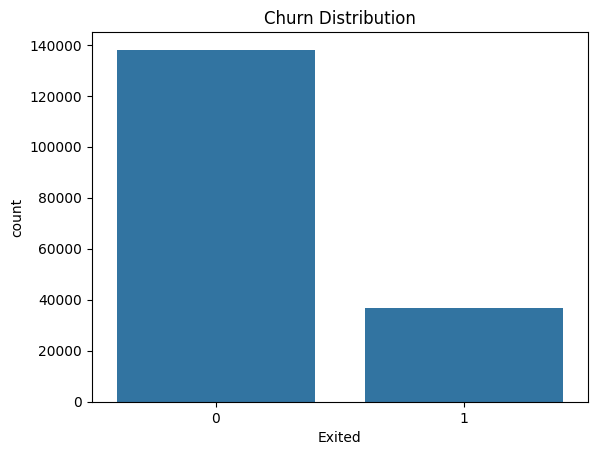

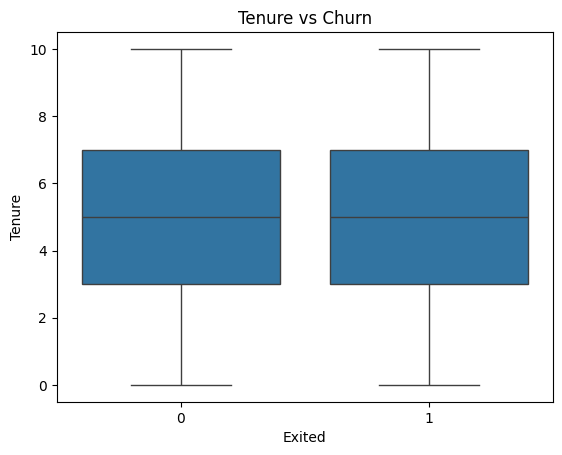

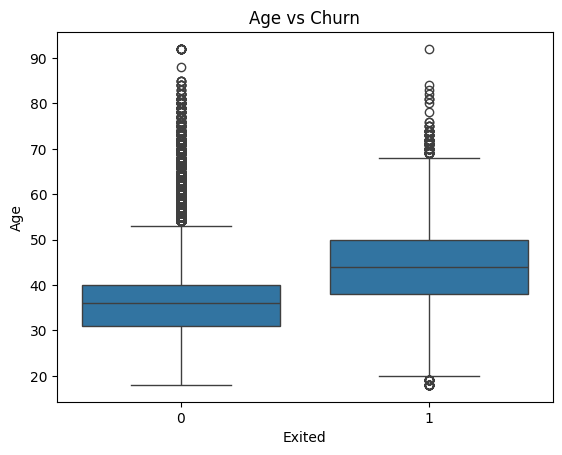

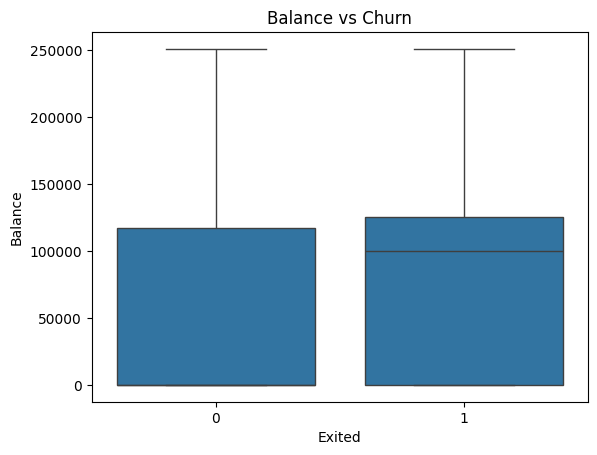

In [ ]:
# EDA: Understand why customers churn, not just predict it.
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

sns.boxplot(x='Exited', y='Tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn")
plt.show()


In [ ]:
# train-test split
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (140022, 13)
Test shape: (35006, 13)


In [ ]:
# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# model training
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)
X_scaled_full = scaler.transform(X)


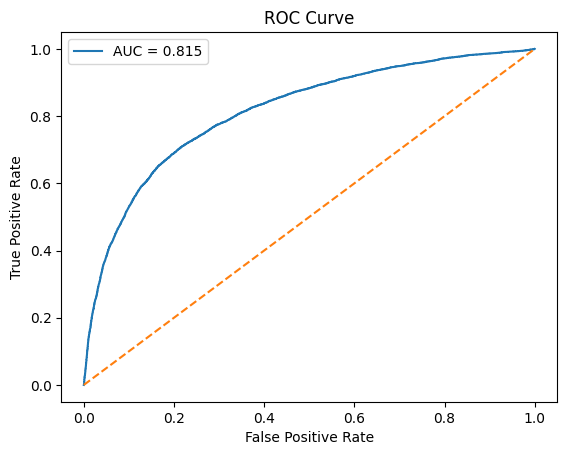

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for test set
probs_test = model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, probs_test)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
import numpy as np

j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)

Best Threshold: 0.524553184140888


In [ ]:
# Predictions for ALL rows (not just test)
# Get probabilities
probs = model.predict_proba(X_scaled_full)[:, 1]

# Apply custom threshold
df['Predicted_Exited'] = (probs >= best_threshold).astype(int)

# Risk segmentation
def risk_category(p):
    if p >= 0.6:
        return "High Risk"
    elif p >= 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Segment'] = df['Churn_Prob'].apply(risk_category)

# Also store probabilities
df['Churn_Prob'] = probs

In [ ]:
df['Pred_0_3'] = (df['Churn_Prob'] >= 0.3).astype(int)
df['Pred_0_4'] = (df['Churn_Prob'] >= 0.4).astype(int)
df['Pred_0_5255'] = (df['Churn_Prob'] >= best_threshold).astype(int)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Get probabilities
probs_test = model.predict_proba(X_test_scaled)[:, 1]

# Apply your custom threshold
y_pred = (probs_test >= best_threshold).astype(int)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7672399017311318

Confusion Matrix:
[[21606  6000]
 [ 2148  5252]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84     27606
           1       0.47      0.71      0.56      7400

    accuracy                           0.77     35006
   macro avg       0.69      0.75      0.70     35006
weighted avg       0.82      0.77      0.78     35006



In [ ]:
df.to_csv("final_churn_data.csv", index=False)

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

feature_importance.to_csv("feature_importance.csv", index=False)

In [ ]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))